## Import Liabraries and Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#plt.style.use("seaborn-v0_8")
#sns.set_palette("tab10")

df = pd.read_csv("CarDekho_India_UsedCars_CLEANED.csv")
df.head()
df

,Year,City,Brand,Model,Variant,Price,Old Price,Savings,Transmission,Fuel_Type,KM_Driven
0,2024,delhi,Kia,Sonet,HTK Plus,840000,840000,0,Manual,Petrol,10000
1,2022,delhi,Renault,Kiger,RXZ,575000,575000,0,Manual,Petrol,50214
2,2024,delhi,Nissan,Magnite,XV,680000,680000,0,Manual,Petrol,19000
3,2022,delhi,Renault,Kiger,RXT Opt,550000,550000,0,Manual,Petrol,14464
4,2022,delhi,Kia,Sonet,HTX Turbo iMT BSVI,800000,800000,0,Manual,Petrol,37741
...,...,...,...,...,...,...,...,...,...,...,...
15595,2023,chandigarh,Maruti,Alto,K10 VXI,380000,419000,39131,Manual,Petrol,28199
15596,2024,chandigarh,MG,Astor,Select CVT,1250000,1250000,0,Automatic,Petrol,20000
15597,2024,chandigarh,Mahindra,XUV,3XO MX3,850000,850000,0,Manual,Petrol,8000
15598,2024,chandigarh,Kia,Sonet,HTX Turbo iMT,1070000,1070000,0,Manual,Petrol,17000


## 1) Basic Overview

In [3]:
print(df.shape)
df.info()
df.describe()
df.isnull().sum()


(15600, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15600 entries, 0 to 15599
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Year          15600 non-null  int64 
 1   City          15600 non-null  object
 2   Brand         15600 non-null  object
 3   Model         15600 non-null  object
 4   Variant       15600 non-null  object
 5   Price         15600 non-null  int64 
 6   Old Price     15600 non-null  int64 
 7   Savings       15600 non-null  int64 
 8   Transmission  15600 non-null  object
 9   Fuel_Type     15600 non-null  object
 10  KM_Driven     15600 non-null  int64 
dtypes: int64(5), object(6)
memory usage: 1.3+ MB


Year            0
City            0
Brand           0
Model           0
Variant         0
Price           0
Old Price       0
Savings         0
Transmission    0
Fuel_Type       0
KM_Driven       0
dtype: int64

In [4]:
#convert year -> object 
df["Year"] = df["Year"].astype(str)

In [5]:
print(df.shape)
df.info()
df.describe()
df.isnull().sum()


(15600, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15600 entries, 0 to 15599
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Year          15600 non-null  object
 1   City          15600 non-null  object
 2   Brand         15600 non-null  object
 3   Model         15600 non-null  object
 4   Variant       15600 non-null  object
 5   Price         15600 non-null  int64 
 6   Old Price     15600 non-null  int64 
 7   Savings       15600 non-null  int64 
 8   Transmission  15600 non-null  object
 9   Fuel_Type     15600 non-null  object
 10  KM_Driven     15600 non-null  int64 
dtypes: int64(4), object(7)
memory usage: 1.3+ MB


Year            0
City            0
Brand           0
Model           0
Variant         0
Price           0
Old Price       0
Savings         0
Transmission    0
Fuel_Type       0
KM_Driven       0
dtype: int64

In [6]:
fuel_counts_df = df["Fuel_Type"].value_counts(dropna=False).reset_index()
fuel_counts_df.columns = ["Fuel_Type", "Count"]
fuel_counts_df


,Fuel_Type,Count
0,Petrol,13491
1,Diesel,2109


C:\Users\vaish\AppData\Local\Temp\ipykernel_22556\2980906786.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.values, y=top_brands.index, palette="viridis")


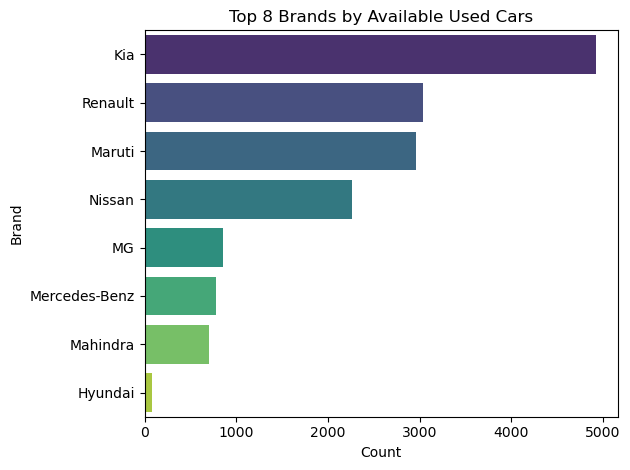

In [7]:
plt.figure()
top_brands = df['Brand'].value_counts().head(15)
sns.barplot(x=top_brands.values, y=top_brands.index, palette="viridis")
plt.title("Top 8 Brands by Available Used Cars")
plt.xlabel("Count")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

C:\Users\vaish\AppData\Local\Temp\ipykernel_22556\1385718496.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


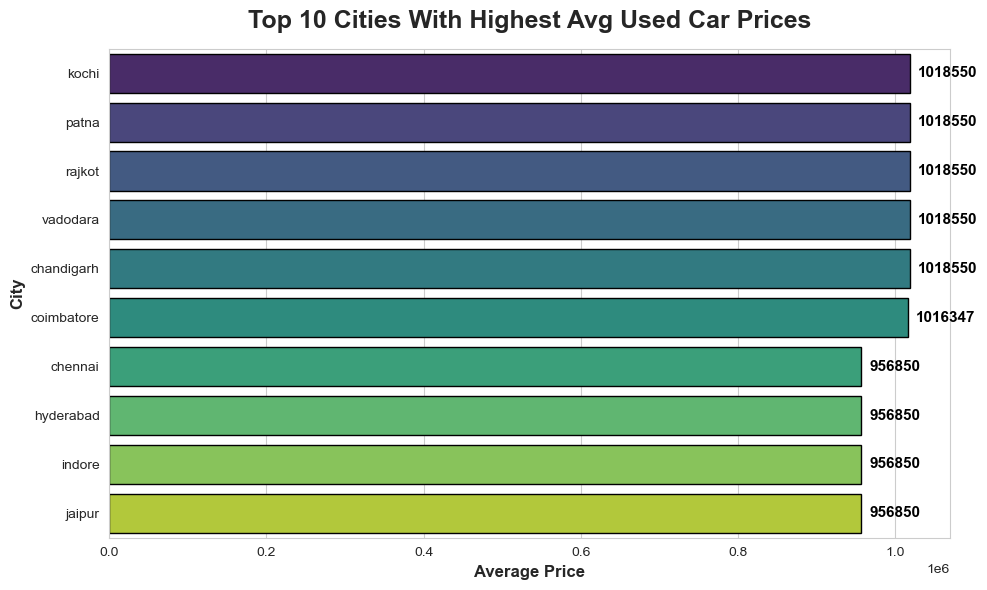

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data
city_price = df.groupby("City")["Price"].mean().sort_values(ascending=False).head(10)

# Create gradient colors
colors = sns.color_palette("viridis", n_colors=10)   # bright + modern

plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

bars = sns.barplot(
    x=city_price.values,
    y=city_price.index,
    palette=colors,
    linewidth=1,
    edgecolor="black"
)

# Add value labels on each bar (professional look)
for i, v in enumerate(city_price.values):
    plt.text(
        v + (v*0.01),       # position slightly outside bar
        i,
        f"{int(v)}",
        color="black",
        fontsize=11,
        va="center",
        fontweight="bold"
    )

# Title + labels styling
plt.title("Top 10 Cities With Highest Avg Used Car Prices",
          fontsize=18, weight="bold", pad=15)
plt.xlabel("Average Price", fontsize=12, weight="bold")
plt.ylabel("City", fontsize=12, weight="bold")

plt.tight_layout()
plt.show()



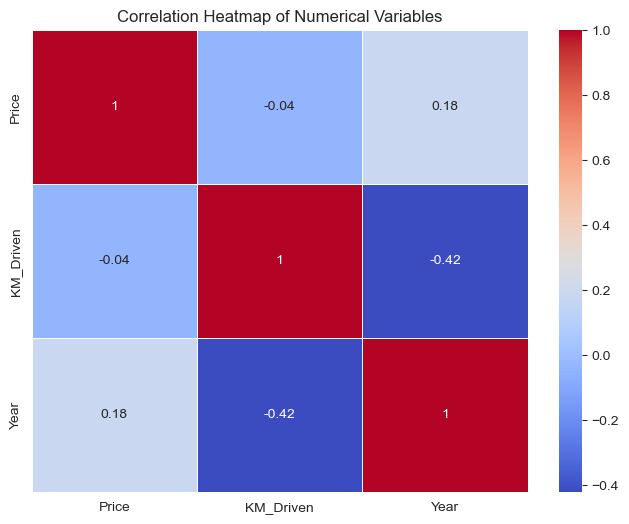

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['Price','KM_Driven','Year']].corr(),
            annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#plt.style.use("seaborn-v0_8")
#sns.set_palette("tab10")

df = pd.read_csv("CarDekho_India_UsedCars_CLEANED.csv")
df.head()
df

,Year,City,Brand,Model,Variant,Price,Old Price,Savings,Transmission,Fuel_Type,KM_Driven
0,2024,delhi,Kia,Sonet,HTK Plus,840000,840000,0,Manual,Petrol,10000
1,2022,delhi,Renault,Kiger,RXZ,575000,575000,0,Manual,Petrol,50214
2,2024,delhi,Nissan,Magnite,XV,680000,680000,0,Manual,Petrol,19000
3,2022,delhi,Renault,Kiger,RXT Opt,550000,550000,0,Manual,Petrol,14464
4,2022,delhi,Kia,Sonet,HTX Turbo iMT BSVI,800000,800000,0,Manual,Petrol,37741
...,...,...,...,...,...,...,...,...,...,...,...
15595,2023,chandigarh,Maruti,Alto,K10 VXI,380000,419000,39131,Manual,Petrol,28199
15596,2024,chandigarh,MG,Astor,Select CVT,1250000,1250000,0,Automatic,Petrol,20000
15597,2024,chandigarh,Mahindra,XUV,3XO MX3,850000,850000,0,Manual,Petrol,8000
15598,2024,chandigarh,Kia,Sonet,HTX Turbo iMT,1070000,1070000,0,Manual,Petrol,17000


C:\Users\vaish\AppData\Local\Temp\ipykernel_22556\2561465677.py:8: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.countplot(


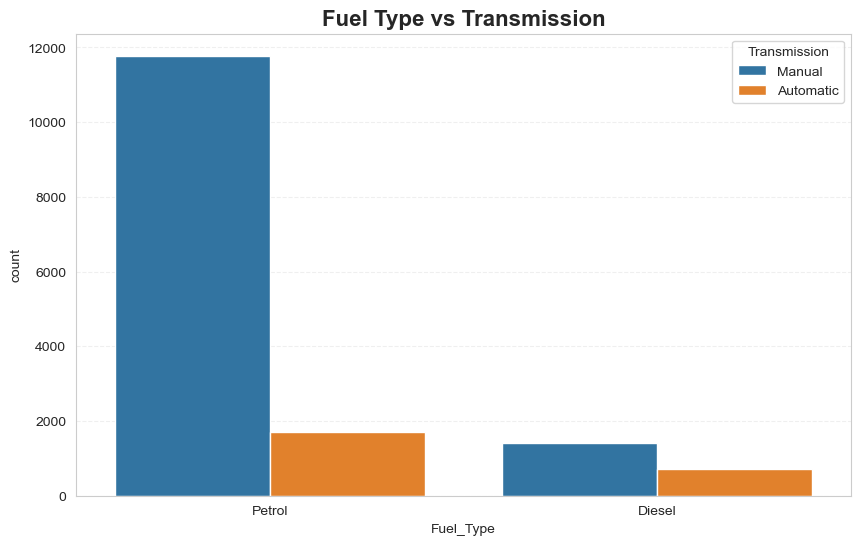

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))

corporate_bright = ["#1F77B4", "#FF7F0E", "#2CA02C", "#D62728", "#9467BD"]

sns.countplot(
    data=df,
    x='Fuel_Type',
    hue='Transmission',
    palette=corporate_bright
)

plt.title("Fuel Type vs Transmission", fontsize=16, weight="bold")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()


C:\Users\vaish\AppData\Local\Temp\ipykernel_22556\1664104680.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


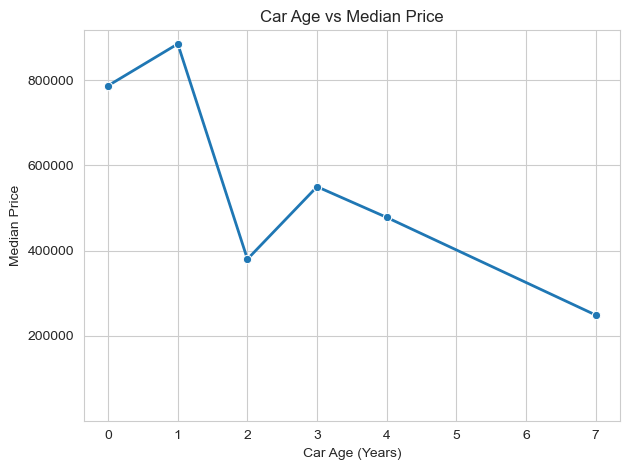

In [14]:
df["Car_Age"] = 2025 - df["Year"]

plt.figure()
sns.lineplot(
    data=df,
    x="Car_Age",
    y="Price",
    estimator="median",
    lw=2,
    marker="o",
    ci=None        # ❌ removes shaded confidence interval
)

plt.title("Car Age vs Median Price")
plt.xlabel("Car Age (Years)")
plt.ylabel("Median Price")
plt.ylim(bottom=1000)

plt.tight_layout()
plt.show()
